# 누적 복습 1. 온라인 광고 클릭 분류

## 난이도
- 간단한 복습 문제

## 데이터셋 설명
- 수업 복습용으로 생성한 가상 온라인 광고 클릭 데이터셋임.
- 실제 고객 데이터가 아니라, 재현 가능한 난수로 만든 학습용 데이터임.
- 모든 feature가 수치형이므로, 지금까지 수업에서 다룬 표 형태 데이터 처리 흐름 그대로 사용할 수 있음.
- target은 `clicked`이며, 사용자가 광고를 클릭했는지 나타냄.
  - `0`: 클릭하지 않음
  - `1`: 클릭함

## 컬럼 설명
- `age`: 사용자 나이
- `daily_site_minutes`: 하루 평균 사이트 이용 시간
- `ad_frequency`: 최근 광고 노출 횟수
- `previous_purchases`: 이전 구매 횟수
- `discount_rate`: 광고에 포함된 할인율
- `page_views`: 최근 페이지 조회 수

## 복습 범위
- feature/target 분리
- 학습/평가 데이터 분리
- 스케일링
- KNN, Logistic Regression, Random Forest 비교
- 분류 모델 평가와 새 데이터 예측


In [12]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rng = np.random.default_rng(42)
n_samples = 700

age = rng.integers(18, 65, n_samples)
daily_site_minutes = rng.normal(38, 14, n_samples).clip(3, 100)
ad_frequency = rng.poisson(4.0, n_samples).clip(0, 15)
previous_purchases = rng.poisson(1.4, n_samples).clip(0, 10)
discount_rate = rng.choice([0, 5, 10, 15, 20, 30], n_samples, p=[0.18, 0.20, 0.24, 0.18, 0.14, 0.06])
page_views = rng.normal(8, 4, n_samples).clip(1, 30)

# 광고 클릭 확률을 만들기 위한 가상 규칙.
# 사이트 이용 시간이 길고, 이전 구매가 많고, 할인율이 높으면 클릭 확률이 올라가도록 구성함.
# 광고 노출이 너무 많으면 피로도가 생긴다고 보고 일부 감점 효과를 넣음.
logit = (
    -4.0
    + 0.035 * daily_site_minutes
    + 0.30 * previous_purchases
    + 0.055 * discount_rate
    + 0.08 * page_views
    - 0.08 * ad_frequency
    - 0.012 * (age - 35)
)
click_proba = 1 / (1 + np.exp(-logit))
clicked = rng.binomial(1, click_proba)

ad_df = pd.DataFrame({
    'age': age,
    'daily_site_minutes': daily_site_minutes.round(1),
    'ad_frequency': ad_frequency,
    'previous_purchases': previous_purchases,
    'discount_rate': discount_rate,
    'page_views': page_views.round(1),
    'clicked': clicked
})

X = ad_df.drop('clicked', axis=1)
y = ad_df['clicked']

print('데이터 크기:', ad_df.shape)
print('클릭 비율:', y.mean().round(3))
display(ad_df.head())


데이터 크기: (700, 7)
클릭 비율: 0.233


,age,daily_site_minutes,ad_frequency,previous_purchases,discount_rate,page_views,clicked
0,22,42.4,7,0,5,5.7,0
1,54,54.2,9,1,10,2.4,1
2,48,46.5,3,3,0,9.8,1
3,38,5.9,5,2,10,1.0,0
4,38,42.3,0,1,15,12.4,1


## 문제 1. 데이터 분리와 스케일링

광고 클릭 데이터를 학습용과 평가용으로 나누고 스케일링하세요.

### 요구사항
- `train_test_split()` 사용
- `test_size=0.2`, `random_state=42`, `stratify=y` 사용
- `StandardScaler()` 사용
- 학습 데이터에는 `fit_transform()`, 평가 데이터에는 `transform()` 사용
- 분리 결과 shape 출력

### 힌트
- KNN과 Logistic Regression은 feature 값의 크기 차이에 영향을 받을 수 있음.
- `daily_site_minutes`, `discount_rate`, `page_views`처럼 단위가 다른 feature를 비슷한 기준으로 맞추는 과정이 스케일링임.


In [13]:
# 작성: train_test_split()으로 학습/평가 데이터를 분리하세요.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42)

# 작성: 분리 결과 shape를 출력하세요.
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

# 작성: StandardScaler()로 학습/평가 데이터를 스케일링하세요.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 작성: 분리 결과 shape를 출력하세요.
print(X_train_scaled.shape, y_train.shape)
print(X_test_scaled.shape, y_test.shape)


X_train: (560, 6)
X_test: (140, 6)
y_train: (560,)
y_test: (140,)
(560, 6) (560,)
(140, 6) (140,)


## 문제 2. 분류 모델 3개 성능 비교

KNN, Logistic Regression, Random Forest를 학습하고 평가 데이터 accuracy를 비교하세요.

### 요구사항
- `KNeighborsClassifier(n_neighbors=5)` 사용
- `LogisticRegression(max_iter=2000, random_state=42)` 사용
- `RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)` 사용
- 결과 컬럼: `model`, `train_accuracy`, `test_accuracy`
- 결과를 DataFrame으로 출력

### 힌트
- KNN은 가까운 이웃을 보고 예측함.
- Logistic Regression은 선형식으로 class 확률을 계산함.
- Random Forest는 여러 결정트리의 투표로 최종 class를 예측함.


In [17]:
# 작성: KNN, Logistic Regression, Random Forest 모델을 딕셔너리로 준비하세요.
models = {
    'knn': KNeighborsClassifier(n_neighbors=5),
    'logistic_regression': LogisticRegression(max_iter=5000, random_state=42),
    'random_forest': RandomForestClassifier(n_estimators=200, random_state=42)
}

# 작성: 반복문으로 모델을 학습하고 train/test accuracy를 results에 저장하세요.
results = []
for name, model in models.items():
    model.fit(X_train_scaled, y_train) # train 데이터 학습
    y_pred = model.predict(X_test_scaled) # test 예측값 저장

    results.append({
        'model': name,
        'train_accuracy': accuracy_score(y_train, model.predict(X_train_scaled)),
        'test_accuracy': accuracy_score(y_test, y_pred)
    })

# 작성: 결과를 DataFrame으로 출력하세요.
result_df = pd.DataFrame(results)
display(result_df)

,model,train_accuracy,test_accuracy
0,knn,0.808929,0.757143
1,logistic_regression,0.783929,0.750000
2,random_forest,1.000000,0.728571


## 문제 3. 최종 모델 선택과 새 데이터 예측

평가 accuracy가 가장 높은 모델을 골라 상세 결과를 확인하고, 새 사용자 2명의 광고 클릭 여부를 예측하세요.

### 요구사항
- 문제 2 결과에서 가장 좋은 모델 선택
- `classification_report()` 출력
- 새 사용자 2명 데이터를 DataFrame으로 생성
- 새 데이터에도 기존 scaler의 `transform()` 적용
- 예측 class와 클릭 확률을 출력

### 힌트
- `predict()`는 최종 class를 반환함.
- `predict_proba()`는 class별 확률을 반환함.
- 새 데이터도 학습 데이터와 같은 컬럼 순서로 만들어야 함.


선택한 모델: knn
              precision    recall  f1-score   support

           0       0.76      0.98      0.86       104
           1       0.67      0.11      0.19        36

    accuracy                           0.76       140
   macro avg       0.71      0.55      0.52       140
weighted avg       0.74      0.76      0.69       140



,age,daily_site_minutes,ad_frequency,previous_purchases,discount_rate,page_views,pred_class,click_proba
0,28,70,3,2,0.15,8,0,0.2
1,52,40,8,0,0.05,3,0,0.0


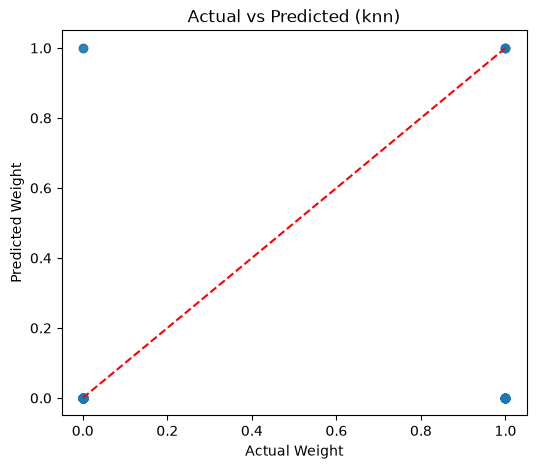

In [20]:
# 작성: result_df에서 평가 accuracy가 가장 높은 모델 이름을 찾으세요.
best_model_name = result_df.sort_values('test_accuracy', ascending=False).iloc[0]['model']
print('선택한 모델:', best_model_name)
best_model = models[best_model_name]

# 작성: 선택한 모델로 평가 데이터를 예측하고 classification_report()를 출력하세요.
y_pred = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred))

# 작성: 새 사용자 2명의 데이터를 만들고 클릭 여부와 클릭 확률을 예측하세요.
new_users = pd.DataFrame([
    {
        'age': 28,
        'daily_site_minutes': 70,
        'ad_frequency': 3,
        'previous_purchases': 2,
        'discount_rate': 0.15,
        'page_views': 8
    },
    {
        'age': 52,
        'daily_site_minutes': 40,
        'ad_frequency': 8,
        'previous_purchases': 0,
        'discount_rate': 0.05,
        'page_views': 3
    }
])

# 학습 데이터와 같은 컬럼 순서로 맞추기
new_users = new_users[X_train.columns]

# 기존 scaler로 transform
new_users_scaled = scaler.transform(new_users)

# 예측 class
new_pred = best_model.predict(new_users_scaled)

# 클릭 확률, class 1 확률
new_proba = best_model.predict_proba(new_users_scaled)[:, 1]

# 결과 출력
new_result_df = new_users.copy()
new_result_df['pred_class'] = new_pred
new_result_df['click_proba'] = new_proba

display(new_result_df)

# 평가 데이터 예측값
test_pred = best_model.predict(X_test_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(y_test, test_pred, alpha=0.7)

plt.xlabel('Actual Weight')
plt.ylabel('Predicted Weight')
plt.title(f'Actual vs Predicted ({best_model_name})')

# 대각선 기준선
min_value = min(y_test.min(), test_pred.min())
max_value = max(y_test.max(), test_pred.max())
plt.plot([min_value, max_value], [min_value, max_value], color='red', linestyle='--')

plt.show()